In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# STEP 2: Set Dataset Path
import os
base_dir = r'C:\Users\hp\Downloads\Okra DiseaseNet Dataset.zip'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.preprocessing import image

# Parameters
img_height, img_width = 224, 224
batch_size = 32
epochs = 10

train_dir = '/content/drive/MyDrive/leaf_disease_dataset/train'
val_dir = '/content/drive/MyDrive/leaf_disease_dataset/validation'
test_dir = '/content/drive/MyDrive/leaf_disease_dataset/test'


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
img_height, img_width = 224, 224
batch_size = 32

# Paths to your dataset folders
train_dir = '/content/drive/MyDrive/leaf_disease_dataset/leaf_disease_dataset/Train'
val_dir =   '/content/drive/MyDrive/leaf_disease_dataset/leaf_disease_dataset/Validation'

# Training data generator with augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.15,
    fill_mode='nearest'
)

# Validation data generator — only rescaling
val_datagen = ImageDataGenerator(rescale=1./255)

# Load and preprocess training images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Load and preprocess validation images
validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)



Found 1109 images belonging to 6 classes.
Found 236 images belonging to 6 classes.


In [ ]:
# STEP 5: Build VGG16 Model
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

for layer in base_model.layers:
    layer.trainable = False  # Freeze base model

x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,563,334 (105.15 MB)

 Trainable params: 12,848,646 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# STEP 6: Train the Model

epochs = 20
val_dir = '/content/drive/MyDrive/leaf_disease_dataset/leaf_disease_dataset/Validation'
val_generator=(
train_datagen.flow_from_directory(
     val_dir,
     target_size=(img_height,
img_width),
     batch_size=batch_size,
     class_mode='categorical',
     shuffle=False
    )
)

history = model.fit(
    train_generator,
steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=epochs)


Found 236 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1310s 38s/step - accuracy: 0.2778 - loss: 2.0599 - val_accuracy: 0.5446 - val_loss: 1.3422
Epoch 2/20
 1/34 ━━━━━━━━━━━━━━━━━━━━ 10:08 18s/step - accuracy: 0.4688 - loss: 1.3779

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


34/34 ━━━━━━━━━━━━━━━━━━━━ 216s 6s/step - accuracy: 0.4688 - loss: 1.3779 - val_accuracy: 0.5000 - val_loss: 1.3456
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 980s 29s/step - accuracy: 0.4916 - loss: 1.3208 - val_accuracy: 0.5625 - val_loss: 1.1722
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 182s 5s/step - accuracy: 0.5625 - loss: 1.1671 - val_accuracy: 0.5714 - val_loss: 1.1710
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 987s 29s/step - accuracy: 0.5694 - loss: 1.1201 - val_accuracy: 0.6339 - val_loss: 1.0511
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.5938 - loss: 1.0033 - val_accuracy: 0.5759 - val_loss: 1.0466
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1032s 29s/step - accuracy: 0.6265 - loss: 1.0261 - val_accuracy: 0.6384 - val_loss: 0.9458
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 200s 6s/step - accuracy: 0.6875 - loss: 0.8410 - val_accuracy: 0.5982 - val_loss: 0.9862
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1020s 29s/step - accuracy: 0.6410 - loss: 0.9178 - val_accuracy: 0.6830 - val_lo

In [ ]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('/content/drive/MyDrive/leaf_disease_vgg_model.h5')


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory('/content/drive/MyDrive/leaf_disease_dataset/leaf_disease_dataset/Train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
loss, accuracy = model.evaluate(train_generator, steps=train_generator.samples//train_generator.batch_size)
print(f'train Accuracy: {accuracy * 100:.2f}%')
x_batch,y_batch = next(train_generator)
print("batch shape:", x_batch.shape)


Found 1109 images belonging to 6 classes.
34/34 ━━━━━━━━━━━━━━━━━━━━ 857s 25s/step - accuracy: 0.8918 - loss: 0.3694
train Accuracy: 87.96%
batch shape: (32, 224, 224, 3)


In [ ]:
# STEP 7: Evaluate the Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory('/content/drive/MyDrive/leaf_disease_dataset/leaf_disease_dataset/Testing',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples//test_generator.batch_size)
print(f'Test Accuracy: {accuracy * 100:.2f}%')
x_batch,y_batch = next(test_generator)
print("batch shape:", x_batch.shape)


Found 150 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 117s 28s/step - accuracy: 0.8042 - loss: 0.4722
Test Accuracy: 80.47%
batch shape: (32, 224, 224, 3)


In [ ]:
# STEP 8: Save the Model to Google Drive
model.save('/content/drive/MyDrive/leaf_disease_vgg_model.h5')


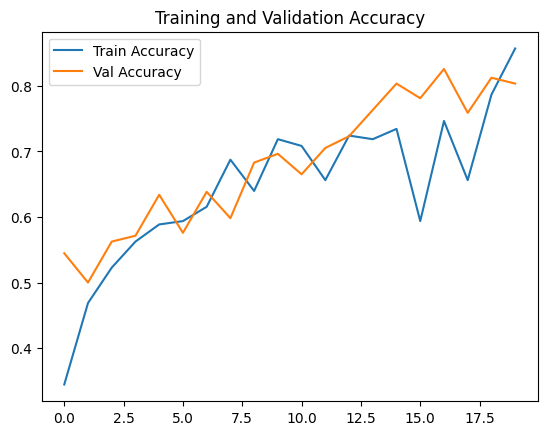

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
Predicted Class: Class 3 - Healthy


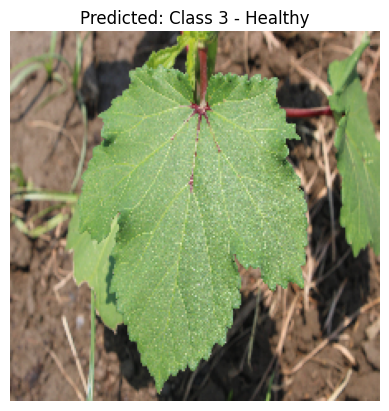

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Set the image path (update this with your image)
img_path = '/content/drive/MyDrive/leaf_disease_dataset/leaf_disease_dataset/Testing/Class 3 - Healthy/H_289.JPG' # Example path

# Load the image and preprocess
# Change the target_size to match the model's input size (224, 224)
img = image.load_img(img_path, target_size=(224, 224))  # Resize to model input size
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Predict using the model
prediction = model.predict(img_array)
predicted_class_index = np.argmax(prediction)
# Assuming train_generator is still available and has the correct class_indices
# If not, you might need to get class_names from a saved source or rebuild from directories
# class_labels = list(train_generator.class_indices.keys()) # Use train_generator
# Make sure train_generator is accessible or re-obtain class names
class_labels = list(validation_generator.class_indices.keys()) # Using val_generator as it was defined earlier and seems accessible

predicted_label = class_labels[predicted_class_index]

# Show result
print(f"Predicted Class: {predicted_label}")

# Optional: Show the image
plt.imshow(img)
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()